In [1]:
import pandas as pd

# === Load data ===
games = pd.read_csv('../NBAdata/Games.csv')
team_histories = pd.read_csv('../NBAdata/TeamHistories.csv')

# === STEP 1: CHECK TEAM IDS ===
games['winner'] = games['winner'].astype(str).str.upper()
games['hometeamId'] = games['hometeamId'].astype(str).str.upper()
games['awayteamId'] = games['awayteamId'].astype(str).str.upper()

# === STEP 2: VERIFY WINNER IS HOME OR AWAY TEAM ===
bad_rows = games[
    (games['winner'] != games['hometeamId']) &
    (games['winner'] != games['awayteamId'])
]
print("✅ Team ID mismatch rows:", bad_rows.shape[0])  # Should be 0

# === STEP 3: CONVERT AND SORT DATES ===
games['gameDate'] = pd.to_datetime(games['gameDate'], errors='coerce')
games = games.sort_values(by='gameDate').reset_index(drop=True)

# === STEP 4a: HOME WIN FLAG ===
games['home_win'] = (games['winner'] == games['hometeamId']).astype(int)

# === STEP 4b: ROLLING HOME WIN RATE (LAST 5 HOME GAMES) ===
games['rolling_home_win_rate'] = (
    games.groupby('hometeamId')['home_win']
    .transform(lambda x: x.shift().rolling(window=5, min_periods=1).mean())
)

# === STEP 4c: HOME WIN STREAK ===
def compute_streaks(results):
    streaks = []
    streak = 0
    for result in results:
        if result == 1:
            streak = streak + 1 if streak >= 0 else 1
        else:
            streak = streak - 1 if streak <= 0 else -1
        streaks.append(streak)
    return streaks

games['home_win_streak'] = (
    games.sort_values('gameDate')
         .groupby('hometeamId')['home_win']
         .transform(compute_streaks)
)

# === STEP 4d: MERGE LATEST TEAM NAME ===
team_histories['teamId'] = team_histories['teamId'].astype(str)
team_names = (
    team_histories
    .sort_values(by='seasonActiveTill', ascending=False)
    .drop_duplicates(subset='teamId')[['teamId', 'teamName']]
)
games = games.drop(columns=[col for col in games.columns if col.startswith('hometeamName')], errors='ignore')
games = games.merge(team_names, left_on='hometeamId', right_on='teamId', how='left')
games = games.rename(columns={'teamName': 'hometeamName'})
games = games.drop(columns=['teamId'])

# === STEP 4e: REMOVE DUPLICATE GAMES ===
games = games.drop_duplicates(subset='gameId').reset_index(drop=True)

# === FINAL SORT (DESCENDING) ===
games = games.sort_values(by='gameDate', ascending=False).reset_index(drop=True)

# === STEP 5: OVERALL WIN RESULTS (HOME + AWAY COMBINED) ===
games['home_team_win'] = (games['winner'] == games['hometeamId']).astype(int)
games['away_team_win'] = (games['winner'] == games['awayteamId']).astype(int)

home_df = games[['gameId', 'gameDate', 'hometeamId', 'home_team_win']].copy()
home_df = home_df.rename(columns={'hometeamId': 'teamId', 'home_team_win': 'win'})

away_df = games[['gameId', 'gameDate', 'awayteamId', 'away_team_win']].copy()
away_df = away_df.rename(columns={'awayteamId': 'teamId', 'away_team_win': 'win'})

team_game_results = pd.concat([home_df, away_df]).sort_values(by='gameDate').reset_index(drop=True)

# === STEP 5a: OVERALL ROLLING WIN RATE ===
team_game_results['rolling_win_rate'] = (
    team_game_results.groupby('teamId')['win']
    .transform(lambda x: x.shift().rolling(window=5, min_periods=1).mean())
)

# === STEP 5b: OVERALL WIN STREAK ===
team_game_results['win_streak'] = (
    team_game_results
    .sort_values(by='gameDate')
    .groupby('teamId')['win']
    .transform(compute_streaks)
)

# === FINAL OUTPUT ===
print("\n✅ Preprocessing Complete")
print(games[['gameDate', 'hometeamId', 'hometeamName', 'home_win', 'rolling_home_win_rate', 'home_win_streak']].head(5))
print(team_game_results[['gameDate', 'teamId', 'win', 'rolling_win_rate', 'win_streak']].tail(5))


/var/folders/h5/0_hjnj_x0wj9602dnkqzthsh0000gn/T/ipykernel_8277/2396310815.py:4: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv('../NBAdata/Games.csv')


✅ Team ID mismatch rows: 0

✅ Preprocessing Complete
             gameDate  hometeamId hometeamName  home_win  \
0 2025-05-05 21:30:00  1610612760      Thunder         0   
1 2025-05-05 19:00:00  1610612738      Celtics         0   
2 2025-05-04 20:30:00  1610612745      Rockets         0   
3 2025-05-04 18:00:00  1610612739    Cavaliers         0   
4 2025-05-03 19:30:00  1610612743      Nuggets         1   

   rolling_home_win_rate  home_win_streak  
0                    0.8               -1  
1                    1.0               -1  
2                    0.6               -1  
3                    0.6               -1  
4                    0.6                2  
                  gameDate      teamId  win  rolling_win_rate  win_streak
143677 2025-05-04 20:30:00  1610612744    1               0.4           1
143678 2025-05-05 19:00:00  1610612738    0               0.8          -1
143679 2025-05-05 19:00:00  1610612752    1               0.6           2
143680 2025-05-05 21:30:00

In [8]:
# Filter team_game_results to only include games from 2024-10-01 onward
season_start = pd.to_datetime('2024-10-01')
this_season = team_game_results[team_game_results['gameDate'] >= season_start]

# Prepare team ID to name mapping
team_names_map = (
    team_histories
    .sort_values(by='seasonActiveTill', ascending=False)
    .drop_duplicates(subset='teamId')[['teamId', 'teamName']]
)
team_names_map['teamId'] = team_names_map['teamId'].astype(str)

# Merge with team_game_results
team_game_results = team_game_results.merge(team_names_map, on='teamId', how='left')


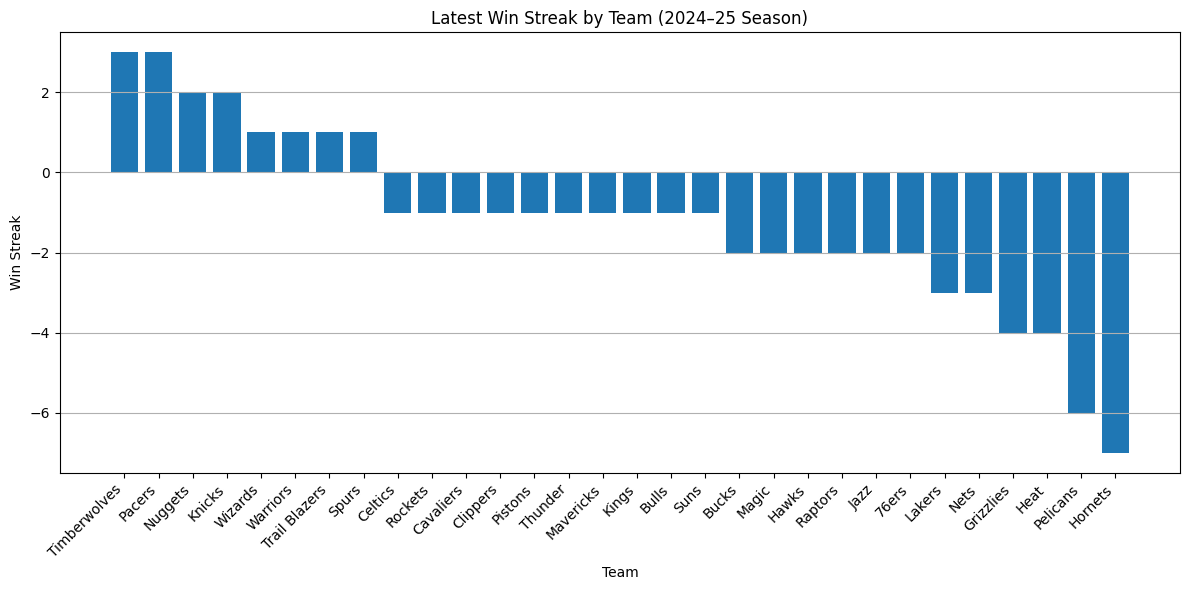

In [9]:
# Filter to current season
season_start = pd.to_datetime('2024-10-01')
this_season = team_game_results[team_game_results['gameDate'] >= season_start]

# Get most recent entry per team
latest_streaks = (
    this_season
    .sort_values('gameDate')
    .groupby('teamId')
    .tail(1)
    .sort_values(by='win_streak', ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(latest_streaks['teamName'], latest_streaks['win_streak'])
plt.title('Latest Win Streak by Team (2024–25 Season)')
plt.xlabel('Team')
plt.ylabel('Win Streak')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()
